In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/final_dataset.csv")

df.head()

,State,Commodity_Group,Commodity,Date,Arrival,Arrival_Unit,Modal_Price,Price_Unit,District,Max_Temp,...,Day,Weekend,DayOfWeek,Quarter,Lag_1,Lag_2,Lag_3,Rolling_7,Rolling_30,Price_Change
0,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Ahmednagar,28.9,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
1,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Pune,29.9,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
2,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nashik,28.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
3,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Solapur,31.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
4,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nagpur,27.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0


In [3]:
df.isnull().sum()

State              0
Commodity_Group    0
Commodity          0
Date               0
Arrival            0
Arrival_Unit       0
Modal_Price        0
Price_Unit         0
District           0
Max_Temp           0
Min_Temp           0
Rainfall_mm        0
Rain_mm            0
WindSpeed          0
Festival           0
Holiday            0
Month              0
Year               0
Day                0
Weekend            0
DayOfWeek          0
Quarter            0
Lag_1              0
Lag_2              0
Lag_3              0
Rolling_7          0
Rolling_30         0
Price_Change       0
dtype: int64

In [4]:
print(df.duplicated().sum())

0


In [5]:
df["Commodity"].value_counts()

Commodity
Wheat     10910
Onion     10890
Potato    10870
Tomato    10870
Rice      10800
Name: count, dtype: int64

 Commodity Count
 Visualization


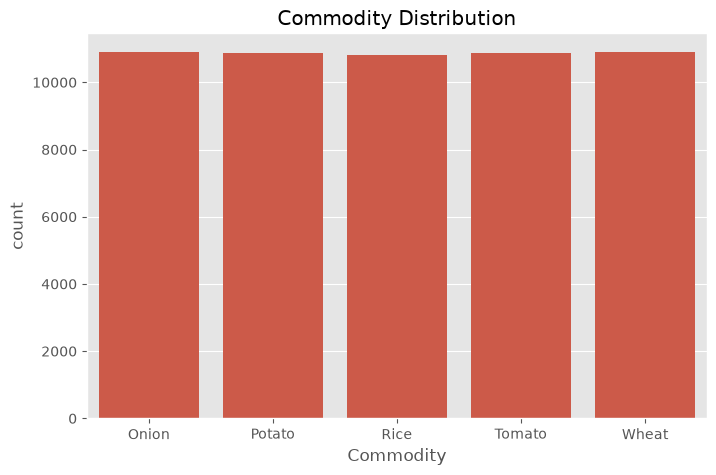

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Commodity"
)

plt.title("Commodity Distribution")

plt.show()

District Count

In [7]:
df["District"].value_counts()

District
Ahmednagar                   5434
Pune                         5434
Nashik                       5434
Solapur                      5434
Nagpur                       5434
Kolhapur                     5434
Sangli                       5434
Satara                       5434
Jalgaon                      5434
Chhatrapati Sambhajinagar    5434
Name: count, dtype: int64

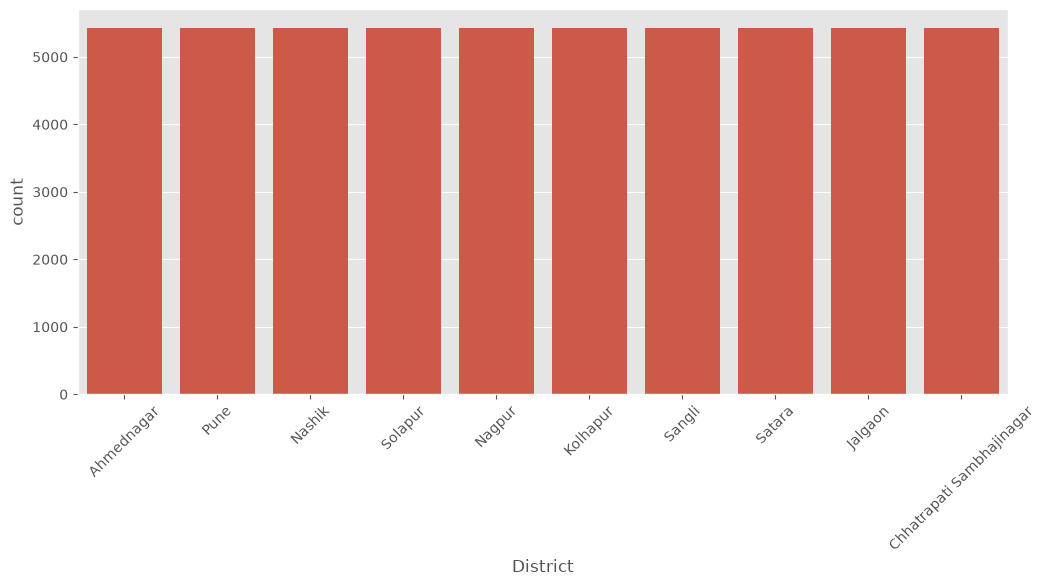

In [8]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="District"
)

plt.xticks(rotation=45)

plt.show()

Price Distribution

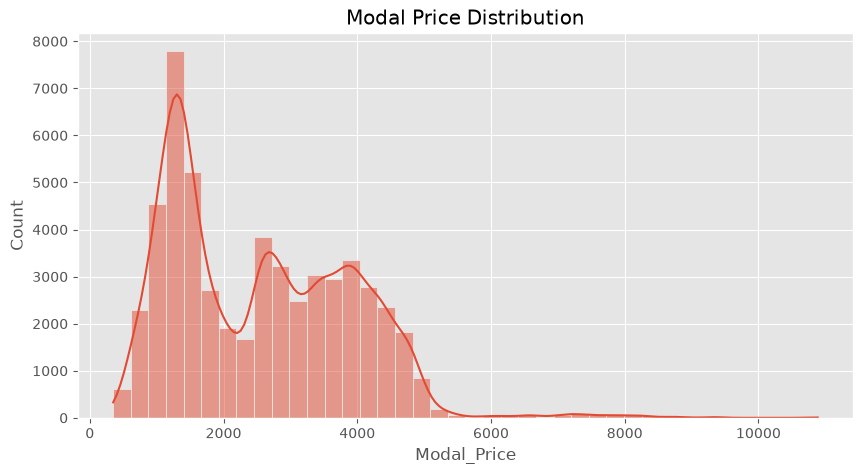

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Modal_Price"],
    bins=40,
    kde=True
)

plt.title("Modal Price Distribution")

plt.show()

Rainfall Distribution

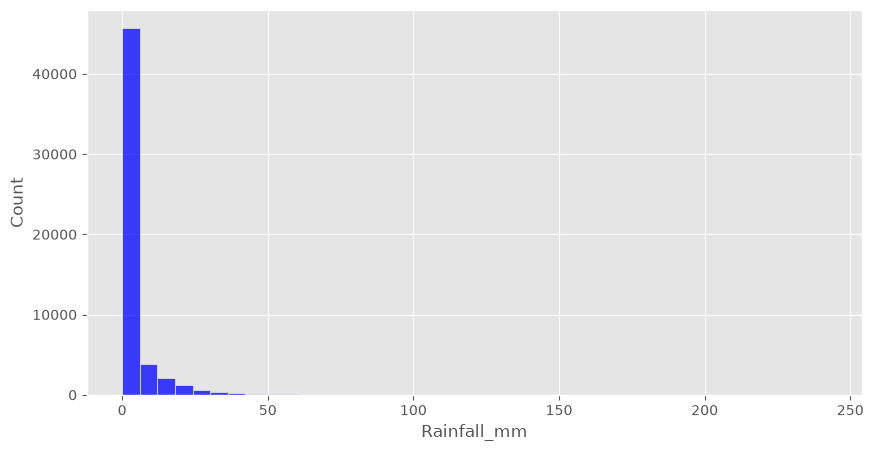

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Rainfall_mm"],
    bins=40,
    color="blue"
)

plt.show()

Temperature Distribution

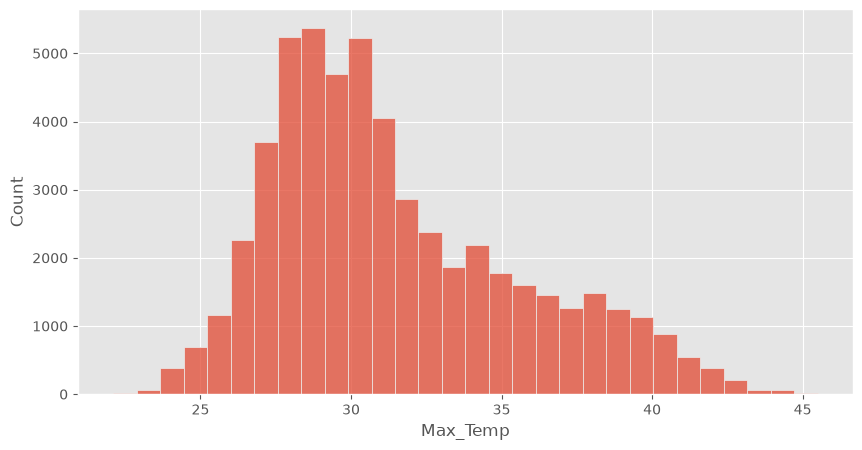

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Max_Temp"],
    bins=30
)

plt.show()

Correlation Heatmap

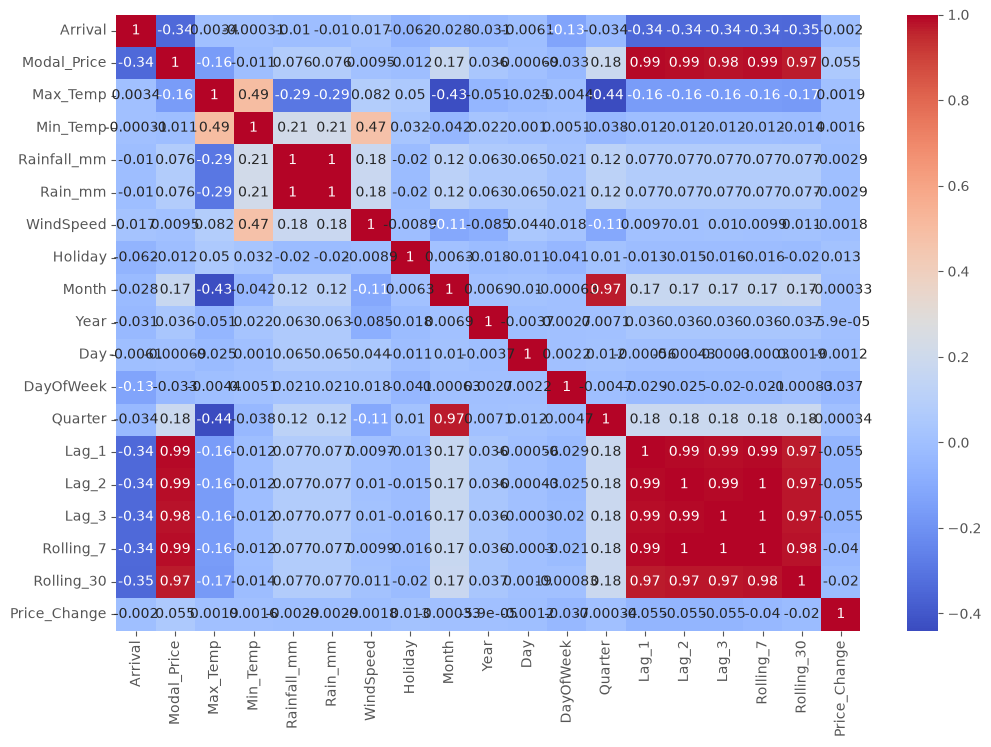

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Monthly Average Price

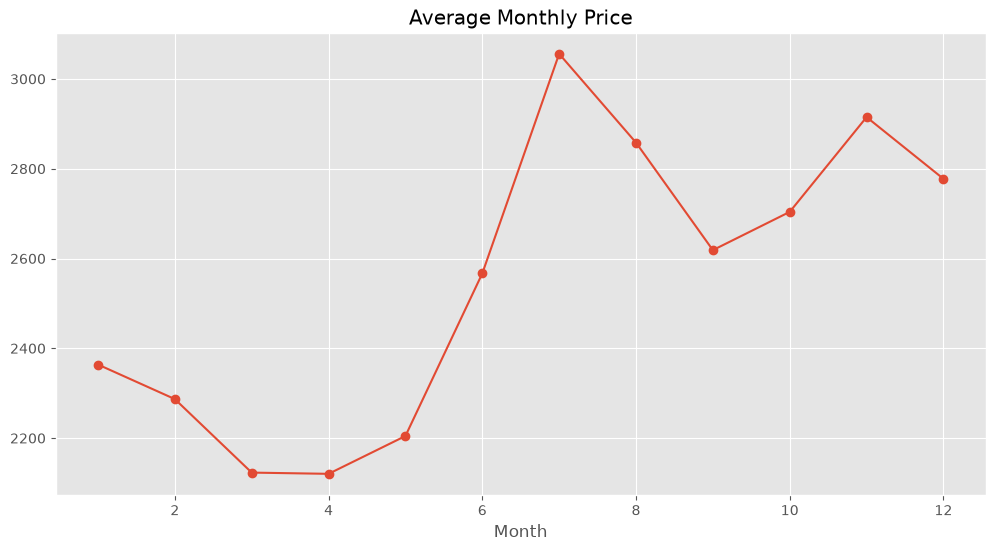

In [13]:
monthly = df.groupby("Month")["Modal_Price"].mean()

monthly.plot(marker="o")

plt.title("Average Monthly Price")

plt.show()

Commodity-wise Price

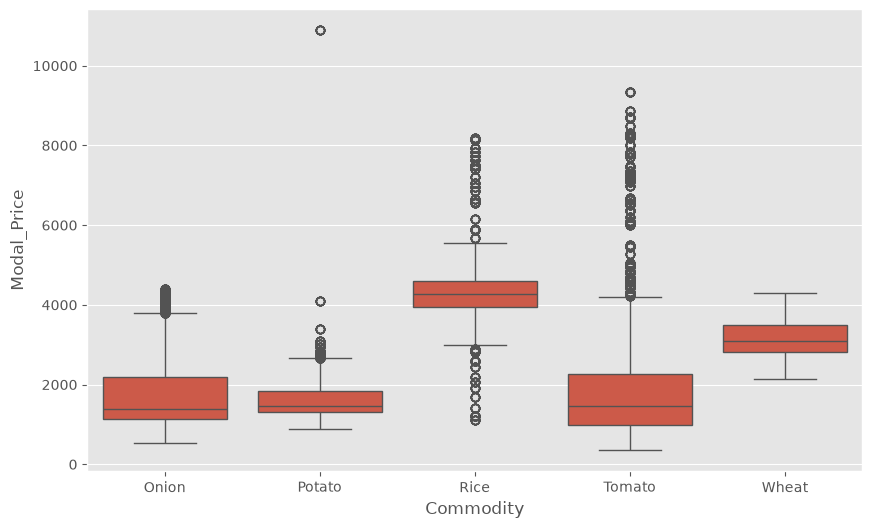

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Commodity",
    y="Modal_Price"
)

plt.show()

Arrival vs Price

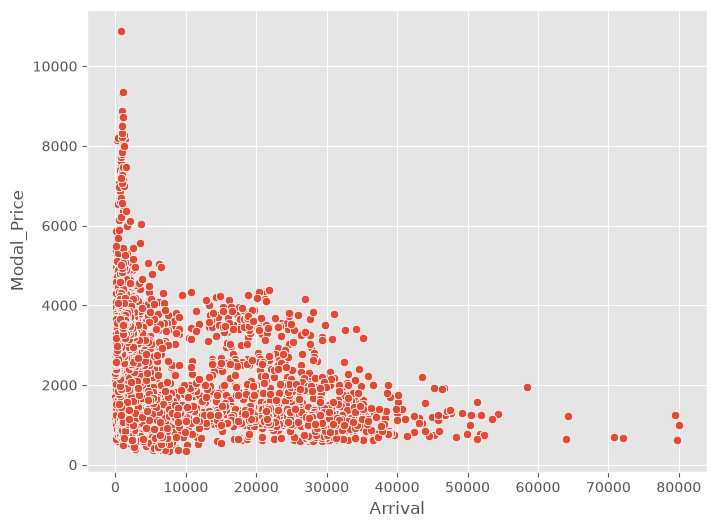

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Arrival",
    y="Modal_Price"
)

plt.show()

Top District Price

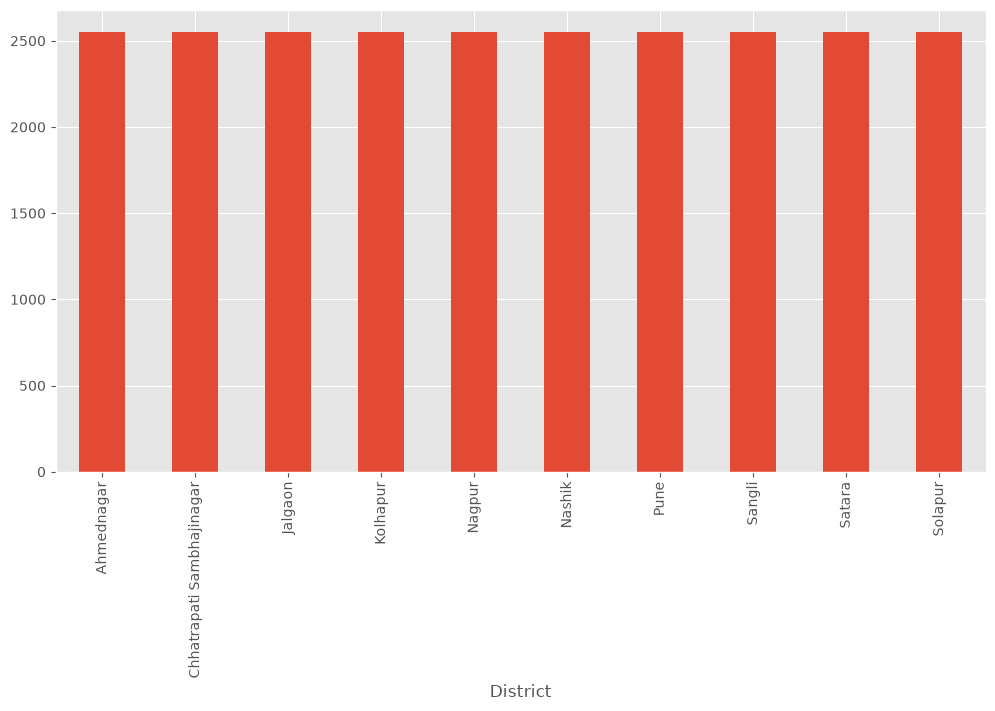

In [16]:
district = df.groupby("District")["Modal_Price"].mean().sort_values()

district.plot(kind="bar")

plt.show()

In [17]:
import joblib

In [18]:
model = joblib.load("../models/price_prediction_model.pkl")

In [19]:
df = pd.read_csv("../data/raw/final_dataset.csv")

In [28]:
features = list(model.feature_names_in_)

In [29]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
17,Lag_1,0.984292
22,Price_Change,0.009821
20,Rolling_7,0.005114
3,Arrival,0.000143
21,Rolling_30,0.000079
15,DayOfWeek,0.000057
12,Year,0.000057
11,Month,0.000055
5,Max_Temp,0.000051
6,Min_Temp,0.000045


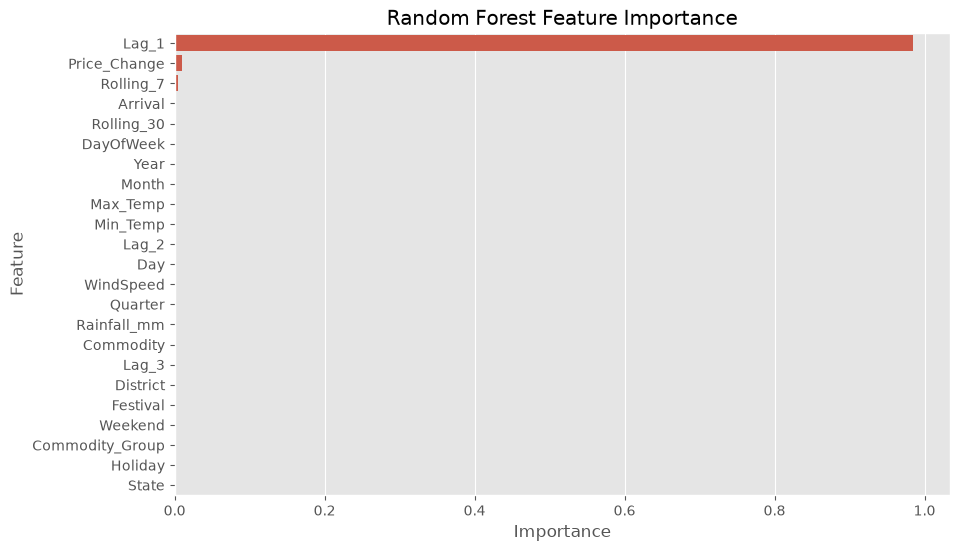

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [25]:
model.feature_names_in_

array(['State', 'Commodity_Group', 'Commodity', 'Arrival', 'District',
       'Max_Temp', 'Min_Temp', 'Rainfall_mm', 'WindSpeed', 'Festival',
       'Holiday', 'Month', 'Year', 'Day', 'Weekend', 'DayOfWeek',
       'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_7', 'Rolling_30',
       'Price_Change'], dtype=object)

In [26]:
features = list(model.feature_names_in_)

In [27]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
17,Lag_1,0.984292
22,Price_Change,0.009821
20,Rolling_7,0.005114
3,Arrival,0.000143
21,Rolling_30,0.000079
15,DayOfWeek,0.000057
12,Year,0.000057
11,Month,0.000055
5,Max_Temp,0.000051
6,Min_Temp,0.000045


In [ ]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Random Forest Feature Importance")

plt.show()